### Preprocess iEEG data

In [8]:
import numpy as np
import mne
import pandas as pd
import mne_bids

from utils import resample, smooth_signal

In [7]:
import sys
!{sys.executable} -m pip install mne-bids

   ---------------------------------------- 0.0/168.9 kB ? eta -:--:--
   ---------------------------------------- 0.0/168.9 kB ? eta -:--:--
   ---- ---------------------------------- 20.5/168.9 kB 320.0 kB/s eta 0:00:01
   --------- ----------------------------- 41.0/168.9 kB 388.9 kB/s eta 0:00:01
   --------- ----------------------------- 41.0/168.9 kB 388.9 kB/s eta 0:00:01
   ---------------- ---------------------- 71.7/168.9 kB 391.3 kB/s eta 0:00:01
   --------------------- ----------------- 92.2/168.9 kB 435.7 kB/s eta 0:00:01
   ----------------------- -------------- 102.4/168.9 kB 392.2 kB/s eta 0:00:01
   --------------------------- ---------- 122.9/168.9 kB 399.4 kB/s eta 0:00:01
   -------------------------------- ----- 143.4/168.9 kB 369.8 kB/s eta 0:00:01
   -------------------------------- ----- 143.4/168.9 kB 369.8 kB/s eta 0:00:01
   ---------------------------------- --- 153.6/168.9 kB 327.3 kB/s eta 0:00:01
   -------------------------------------- 168.9/168.9 kB 3


[notice] A new release of pip is available: 24.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


### Specify subject's directory and meta-information 

In [21]:
# bids_dir='/Fridge/users/julia/project_chill_dataset_paper/data/BIDS2'
bids_dir = r"E:\IEEG-FMRI Dataset"
subjects = mne_bids.get_entity_vals(bids_dir, 'subject')

subject = '01'
acquisition = 'clinical'
task = 'film'
datatype = 'ieeg'
session = 'iemu'
print(subjects)

['01', '02', '03', '04', '05', '06', '07', '08', '09', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '20', '21', '22', '23', '24', '25', '26', '27', '28', '29', '30', '31', '32', '33', '34', '35', '36', '37', '38', '39', '40', '41', '42', '43', '44', '45', '46', '47', '48', '49', '50', '51', '52', '53', '54', '55', '56', '57', '58', '59', '60', '61', '62', '63']


### Load channels

In [22]:
channels_path = mne_bids.BIDSPath(subject=subject,
                                    session=session,
                                    suffix='channels',
                                    extension='tsv',
                                    datatype=datatype,
                                    task=task,
                                    acquisition=acquisition,
                                    root=bids_dir)
channels = pd.read_csv(str(channels_path.match()[0]), sep='\t', header=0, index_col=None)
print(channels)

      name  type units  low_cutoff  high_cutoff reference group  notch status  \
0      AR1  SEEG    µV         NaN         0.15        G2    AR    0.0   good   
1      AR2  SEEG    µV         0.0         0.15        G2    AR    0.0   good   
2      AR3  SEEG    µV         0.0         0.15        G2    AR    0.0   good   
3      AR4  SEEG    µV         0.0         0.15        G2    AR    0.0   good   
4      AR5  SEEG    µV         0.0         0.15        G2    AR    0.0   good   
..     ...   ...   ...         ...          ...       ...   ...    ...    ...   
106   AHL8  SEEG    µV         0.0         0.15        G2   NaN    0.0   good   
107   AHL9  SEEG    µV         0.0         0.15        G2   NaN    0.0   good   
108  thor+   EMG   NaN         0.0         0.00     thor-   NaN    0.0   good   
109  abdo+   EMG   NaN         0.0         0.00     abdo-   NaN    0.0   good   
110  MKR2+  TRIG    µV         0.0         0.00     MKR2-   NaN    0.0   good   

    status_description  sam

### Load data information

In [ ]:
data_path = mne_bids.BIDSPath(subject=subject,
                                    session=session,
                                    suffix='ieeg',
                                    extension='vhdr',
                                    datatype=datatype,
                                    task=task,
                                    acquisition=acquisition,
                                    root=bids_dir)
raw = mne.io.read_raw_brainvision(str(data_path.match()[0]), scale=1.0, preload=False, verbose=True)
raw.set_channel_types({ch_name: str(x).lower()
                if str(x).lower() in ['ecog', 'seeg', 'eeg'] else 'misc'
                                for ch_name, x in zip(raw.ch_names, channels['type'].values)})
raw.drop_channels([raw.ch_names[i] for i, j in enumerate(raw.get_channel_types()) if j == 'misc'])

Extracting parameters from E:/IEEG-FMRI Dataset/sub-01/ses-iemu/ieeg/sub-01_ses-iemu_task-film_acq-clinical_run-1_ieeg.vhdr...
Setting channel info structure...


C:\Users\muqadasah\AppData\Local\Temp\ipykernel_7332\2865297635.py:10: RuntimeWarning: The unit for channel(s) AH+, ECG+, EMG+, MKR1+, MKR2+, ORB+, abdo+, thor+ has changed from V to NA.
  raw.set_channel_types({ch_name: str(x).lower()


<RawBrainVision | sub-01_ses-iemu_task-film_acq-clinical_run-1_ieeg.eeg, 103 x 860254 (420.0 s), ~107 KiB, data not loaded>

### Discard bad channels

In [12]:
bad_channels = channels['name'][(channels['type'].isin(['ECOG', 'SEEG'])) & (channels['status'] == 'bad')].tolist()
raw.info['bads'].extend([ch for ch in bad_channels])
raw.drop_channels(raw.info['bads'])

<RawBrainVision | sub-01_ses-iemu_task-film_acq-clinical_run-1_ieeg.eeg, 101 x 860254 (420.0 s), ~105 KiB, data not loaded>

### Load raw data

In [13]:
raw.load_data()

Reading 0 ... 860253  =      0.000 ...   420.045 secs...


<RawBrainVision | sub-01_ses-iemu_task-film_acq-clinical_run-1_ieeg.eeg, 101 x 860254 (420.0 s), ~663.0 MiB, data loaded>

### Apply notch filter to remove line noise

In [ ]:
raw.notch_filter(freqs=np.arange(50, 251, 50)) #array([50, 100, 150, 200, 250])...includes harmonics as well

Filtering raw data in 1 contiguous segment
Setting up band-stop filter

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandstop filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower transition bandwidth: 0.50 Hz
- Upper transition bandwidth: 0.50 Hz
- Filter length: 13517 samples (6.600 s)



[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.5s
[Parallel(n_jobs=1)]: Done  71 tasks      | elapsed:    3.0s


<RawBrainVision | sub-01_ses-iemu_task-film_acq-clinical_run-1_ieeg.eeg, 101 x 860254 (420.0 s), ~663.0 MiB, data loaded>

### Apply common average reference to remove common noise and trends

In [15]:
raw_car, _ = mne.set_eeg_reference(raw.copy(), 'average')

sEEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('sEEG',) reference.


### Extract signal in gamma range, use Hilbert transform, but can also play around with wavelet decomposition options

In [16]:
gamma = raw_car.copy().filter(60, 120).apply_hilbert(envelope=True).get_data().T

Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 60 - 1.2e+02 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 60.00
- Lower transition bandwidth: 15.00 Hz (-6 dB cutoff frequency: 52.50 Hz)
- Upper passband edge: 120.00 Hz
- Upper transition bandwidth: 30.00 Hz (-6 dB cutoff frequency: 135.00 Hz)
- Filter length: 451 samples (0.220 s)



[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.4s
[Parallel(n_jobs=1)]: Done  71 tasks      | elapsed:    2.1s


In [17]:
# temp = mne.time_frequency.tfr_array_morlet(np.expand_dims(self.raw_car.copy()._data, 0), # (n_epochs, n_channels, n_times)
#                                                      sfreq=self.raw.info['sfreq'],
#                                                      freqs=np.arange(60, 120),
#                                                      verbose=True,
#                                                      n_cycles=4.,
#                                                      n_jobs=1)
# gamma = np.mean(np.abs(temp), 2).squeeze().T

### Read annotation with event markers

Used Annotations descriptions: ['Stimulus/end task', 'Stimulus/music', 'Stimulus/speech']
Using matplotlib as 2D backend.


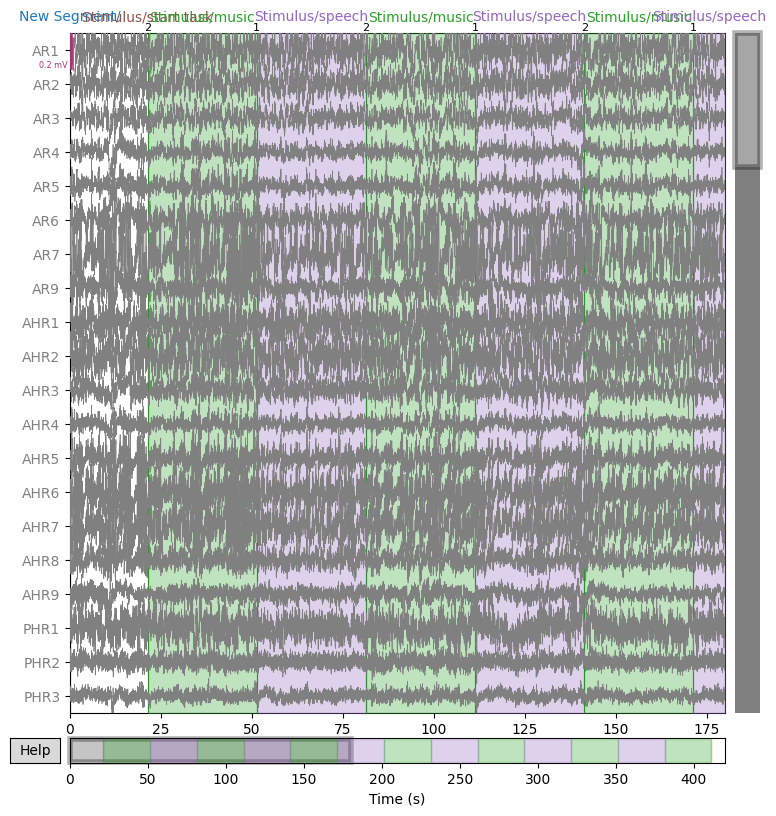

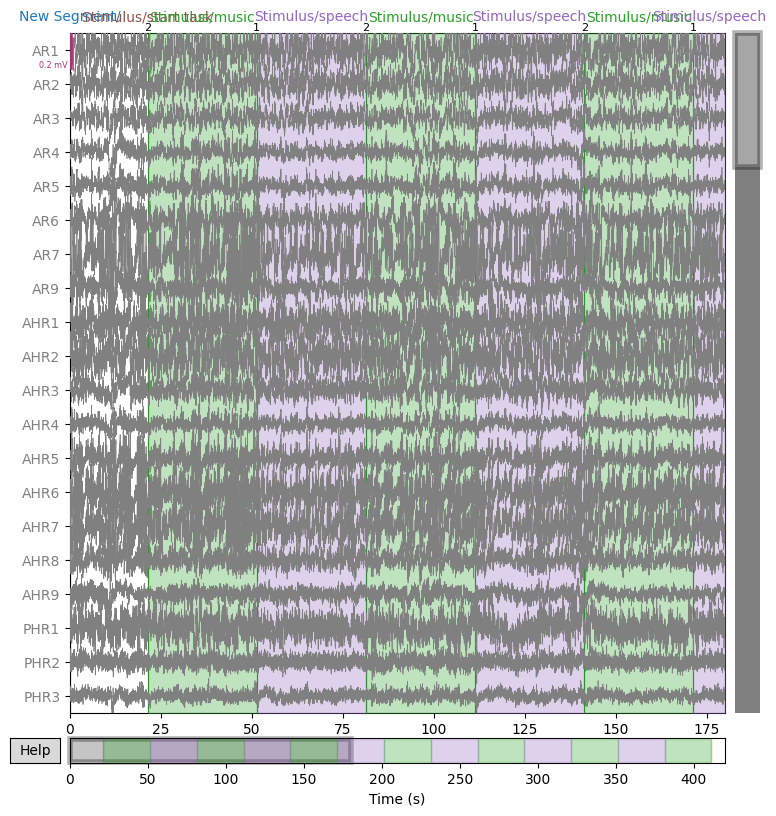

In [18]:
custom_mapping = {'Stimulus/music': 2, 'Stimulus/speech': 1,
                  'Stimulus/end task': 5}  # 'Stimulus/task end' in laan
events, event_id = mne.events_from_annotations(raw_car, event_id=custom_mapping,
                                                         use_rounding=False)

raw_car.plot(events=events, start=0, duration=180, color='gray', event_color={2: 'g', 1: 'r'}, bgcolor='w')

### Crop signal to start and end of the task

In [19]:
gamma_cropped = gamma[events[0, 0]:events[-1, 0]]

### Resample signal to a lower sampling rate

In [20]:
gamma_resampled = resample(gamma_cropped, 25, int(raw.info['sfreq']))